In [13]:
# Import library pendukung
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.utils import resample

# Definisi jalur folder data (sesuaikan dengan direktori Anda)
DATA = Path('/content/drive/MyDrive/Colab Notebooks/data') # Updated path to Google Drive
LOANS_INCOME_CSV = DATA / 'loans_income.csv'
SP500_DATA_CSV = DATA / 'sp500_data.csv'

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


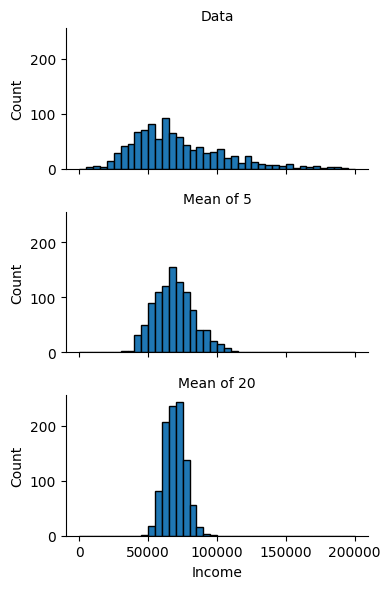

In [12]:
# Memuat data pendapatan pemohon pinjaman (Lending Club)
loans_income = pd.read_csv(LOANS_INCOME_CSV).squeeze('columns')

# Mengambil sampel acak sederhana sebanyak 1000 nilai
sample_data = pd.DataFrame({
    'income': loans_income.sample(1000, random_state=1),
    'type': 'Data',
})

# Mengambil 1000 rata-rata dari sampel berukuran 5
sample_mean_05 = pd.DataFrame({
    'income': [loans_income.sample(5).mean() for _ in range(1000)],
    'type': 'Mean of 5',
})

# Mengambil 1000 rata-rata dari sampel berukuran 20
sample_mean_20 = pd.DataFrame({
    'income': [loans_income.sample(20).mean() for _ in range(1000)],
    'type': 'Mean of 20',
})

# Menggabungkan data untuk divisualisasikan
results = pd.concat([sample_data, sample_mean_05, sample_mean_20])

# Visualisasi histogram (menunjukkan fenomena Central Limit Theorem)
g = sns.FacetGrid(results, col='type', col_wrap=1, height=2, aspect=2)
g.map(plt.hist, 'income', range=[0, 200000], bins=40, edgecolor='black')
g.set_axis_labels('Income', 'Count')
g.set_titles('{col_name}')
plt.tight_layout()
plt.show()

Bootstrap Statistics untuk Median Income:
Original Median: 62000
Bias: -64.79
Standard Error: 196.12

90% Confidence Interval: 61500 hingga 62000


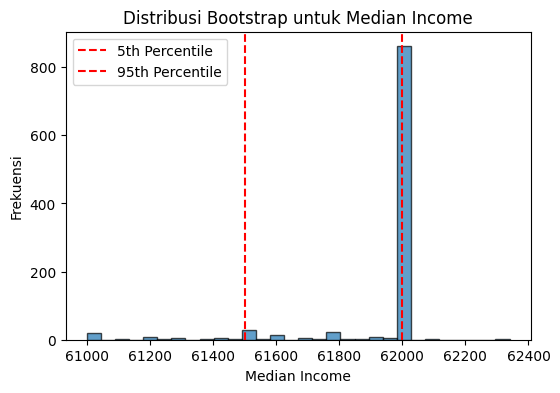

In [14]:
# Implementasi Bootstrap untuk menghitung variabilitas Median Income
results = []
for nrepeat in range(1000):
    # Mengambil sampel dengan pengembalian menggunakan resample dari scikit-learn
    sample = resample(loans_income)
    results.append(sample.median())

results = pd.Series(results)

# Cetak metrik statistik Bootstrap
print('Bootstrap Statistics untuk Median Income:')
print(f'Original Median: {loans_income.median():.0f}')
print(f'Bias: {results.mean() - loans_income.median():.2f}')
print(f'Standard Error: {results.std():.2f}')

# Menghitung 90% Confidence Interval
print(f'\n90% Confidence Interval: {results.quantile(0.05):.0f} hingga {results.quantile(0.95):.0f}')

# Visualisasi Distribusi Bootstrap
plt.figure(figsize=(6, 4))
plt.hist(results, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=results.quantile(0.05), color='red', linestyle='--', label='5th Percentile')
plt.axvline(x=results.quantile(0.95), color='red', linestyle='--', label='95th Percentile')
plt.title('Distribusi Bootstrap untuk Median Income')
plt.xlabel('Median Income')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

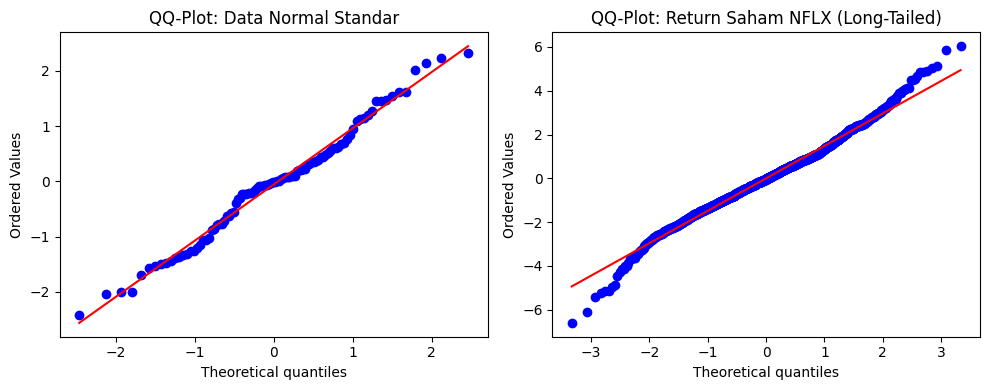

In [15]:
# 1. QQ-Plot dari distribusi normal standar
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

norm_sample = stats.norm.rvs(size=100)
stats.probplot(norm_sample, plot=ax[0])
ax[0].set_title('QQ-Plot: Data Normal Standar')

# 2. QQ-Plot dari Long-Tailed Distribution (Return Saham Netflix)
sp500_px = pd.read_csv(SP500_DATA_CSV, index_col=0)
nflx = sp500_px['NFLX']
nflx = np.diff(np.log(nflx[nflx > 0])) # Menghitung log return

stats.probplot(nflx, plot=ax[1])
ax[1].set_title('QQ-Plot: Return Saham NFLX (Long-Tailed)')

plt.tight_layout()
plt.show()

In [17]:
# Contoh: Probabilitas konversi tepat 2 klik menjadi penjualan dari 5 klik,
# di mana probabilitas konversi per klik adalah 0.1 (10%)
p_exact = stats.binom.pmf(2, n=5, p=0.1)

# Contoh: Probabilitas mendapatkan 2 sukses ATAU KURANG dari 5 percobaan
p_cumulative = stats.binom.cdf(2, n=5, p=0.1)

print(f"Probabilitas tepat 2 sukses (PMF): {p_exact:.4f}")
print(f"Probabilitas 2 sukses atau kurang (CDF): {p_cumulative:.4f}")

Probabilitas tepat 2 sukses (PMF): 0.0729
Probabilitas 2 sukses atau kurang (CDF): 0.9914


<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1663/2921247468.py:17: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_title('Distribusi Poisson ($\lambda=2$)')


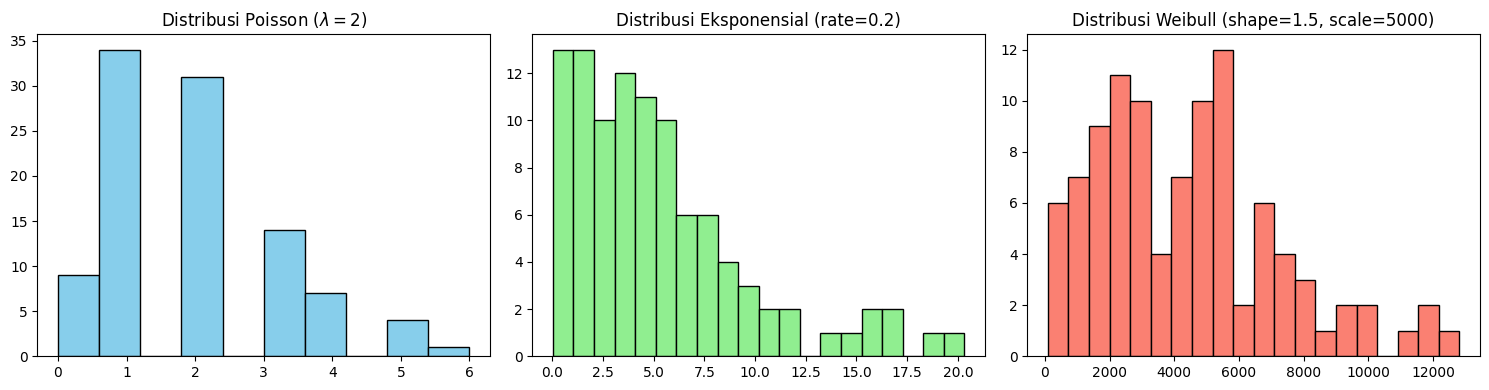

In [18]:
# Menghasilkan sampel acak dari berbagai distribusi

# 1. Poisson: Menghasilkan 100 nilai acak dari distribusi Poisson dengan lambda = 2
poisson_sample = stats.poisson.rvs(2, size=100)

# 2. Eksponensial: Menghasilkan 100 nilai dengan laju = 0.2
# (Dalam scipy.stats.expon, scale adalah 1/rate, jadi scale = 1/0.2 = 5)
exponential_sample = stats.expon.rvs(scale=1/0.2, size=100)

# 3. Weibull: Menghasilkan 100 nilai dengan shape = 1.5 dan scale (characteristic life) = 5000
weibull_sample = stats.weibull_min.rvs(1.5, scale=5000, size=100)

# Visualisasi sederhana
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(poisson_sample, bins=10, edgecolor='black', color='skyblue')
axes[0].set_title('Distribusi Poisson ($\lambda=2$)')

axes[1].hist(exponential_sample, bins=20, edgecolor='black', color='lightgreen')
axes[1].set_title('Distribusi Eksponensial (rate=0.2)')

axes[2].hist(weibull_sample, bins=20, edgecolor='black', color='salmon')
axes[2].set_title('Distribusi Weibull (shape=1.5, scale=5000)')

plt.tight_layout()
plt.show()